/var/folders/pz/q0fdrgtx705cfqr5v6b32w5m0000gp/T/ipykernel_15912/522688055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='pose_label', order=df['pose_label'].value_counts().index, palette='magma')


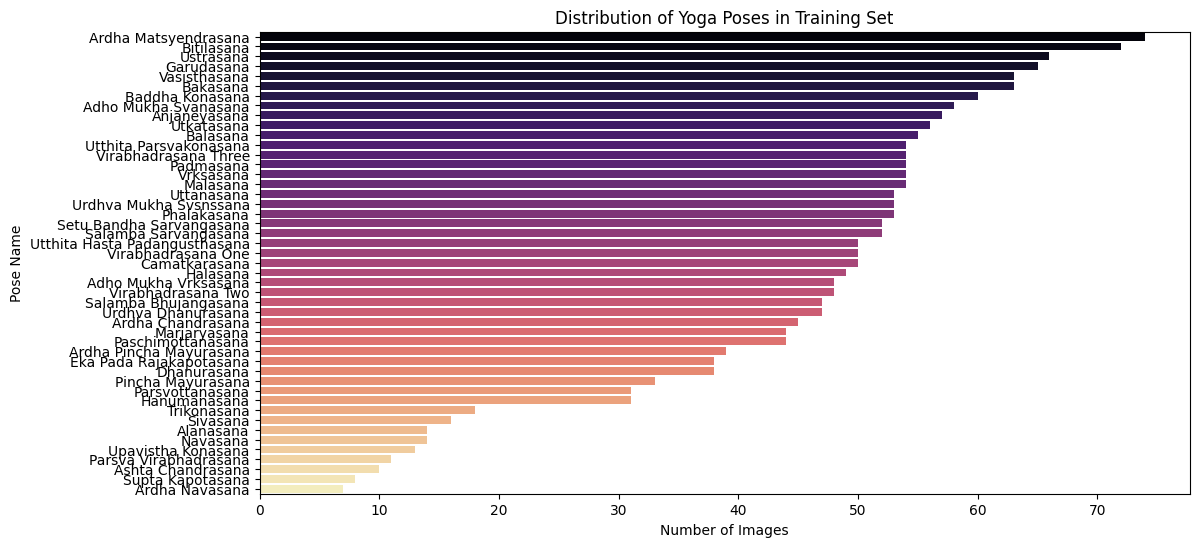

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading  data
df = pd.read_csv('yoga_poses_train.csv')

# The class Distribution Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='pose_label', order=df['pose_label'].value_counts().index, palette='magma')
plt.title('Distribution of Yoga Poses in Training Set')
plt.xlabel('Number of Images')
plt.ylabel('Pose Name')
plt.show()

In [2]:
# Mean and standard deviation 
# Looking into the nose, hypothetically it should not be at the bottom for most of them. 
nose_y_mean = df['y0'].mean()
nose_y_std = df['y0'].std()

# Call outliers as anything that is 3 standard deviations away
outliers = df[(df['y0'] > nose_y_mean + 3 * nose_y_std) | (df['y0'] < nose_y_mean - 3 * nose_y_std)]

print(f"Potential outliers detected based on nose position: {len(outliers)}")

Potential outliers detected based on nose position: 0


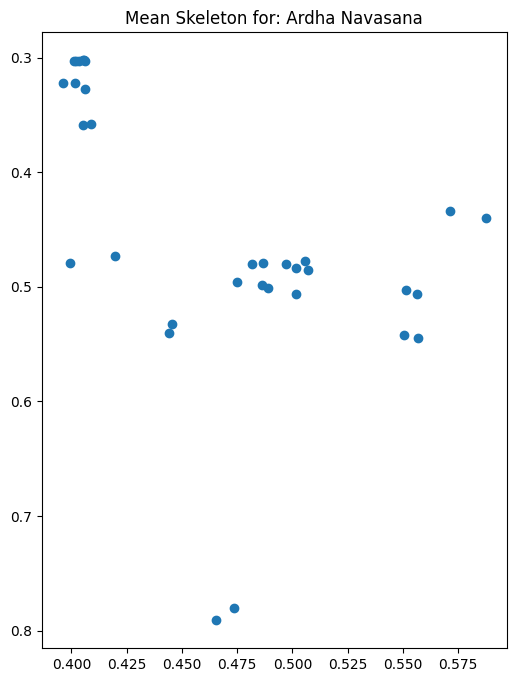

In [3]:
def plot_average_pose(pose_name, dataframe):
    pose_df = dataframe[dataframe['pose_label'] == pose_name]
    
    # Get x and y coordinates
    x_coords = [pose_df[f'x{i}'].mean() for i in range(33)]
    y_coords = [pose_df[f'y{i}'].mean() for i in range(33)]
    
    plt.figure(figsize=(6, 8))
    plt.scatter(x_coords, y_coords)
    
    # Switch Y axis because image coordinates start at the top left
    plt.gca().invert_yaxis()
    plt.title(f'Mean Skeleton for: {pose_name}')
    plt.show()

# Trying it for a random poses.
plot_average_pose(df['pose_label'].unique()[0], df)

In [4]:
# Calculating the spread of the body (Distance between the nose and the ankles)
# This can help find if person is off screen. 
df['body_height'] = abs(df['y0'] - ((df['y31'] + df['y32']) / 2))

# Look for really small skleton, which might be background noise. 
tiny_skeletons = df[df['body_height'] < 0.2]

print(f"Found {len(tiny_skeletons)} samples where the person is barely visible or too small.")

Found 368 samples where the person is barely visible or too small.


In [ ]:
# Filtering out low visibility (anything where MediaPipe was guessing or giving out anamolies)
v_cols = [f'v{i}' for i in range(33)]
df['confidence'] = df[v_cols].mean(axis=1)

# Keep only rows with > 40% confidence
df_cleaned = df[df['confidence'] > 0.4].copy()

# 2. Save the "Golden" dataset for Andrew
df_cleaned.to_csv('yoga_poses_train_cleaned.csv', index=False)

print(f"Cleaned dataset saved! Removed {len(df) - len(df_cleaned)} low-quality rows.")